# Deconvolve the Chromatin
February 5, 2024

In this notebook, we will revisit the deconvolution of the chromatin. Previously, we had deconvolved the chromatin with incorrect CLOCCS parameters. We have now succesfully deconvolved the gene expression with the updated correct FACS fits and CLOCCS parameters that are appropriate to the two replicate experiments we have been working with for RNA-seq and MNase-seq.

So, we should be able to deconvolve the MNase-seq data now and draw inferences from the results.

First, we will see how the deconvolution results look for *CLB2*. Then we will refactor things a bit so we can reuse the configuration files properly from the gene expression deconvolution. There may be other things along the way that we will need to refactor and clean up.

 

In [5]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
from src.config import load_yl_replicate2_rg1_chromatin_config
from src.model import Model

config1 = load_yl_replicate2_rg1_chromatin_config()


In [13]:
from cc_src.chromatin_grid_compute import ChromatinGrid


chromatin_gridder = ChromatinGrid()
chromatin_gridder.set_gene('CLB2', replicate=1)


Loading MNase reads...Done.


In [43]:
chromatin_gridder.create_bins_per_all_sample()

The histogram shape around the TSS is: (6, 17)


In [48]:
chromatin_gridder.define_histogram_bins()

(array([771013, 771053, 771093, 771133, 771173, 771213, 771253, 771293,
        771333, 771373, 771413, 771453, 771493, 771533, 771573, 771613,
        771653, 771693]),
 [50, 100, 122, 145, 170, 195, 225])

The first histogram is shape: (6, 17)
Reshaping this histogram to a vector of shape: (102,)
Then, if we were to take that first vector and restore it to its original shape: (6, 17)
Now we have a data structure that we can try to deconvolve of shape: (15, 102)


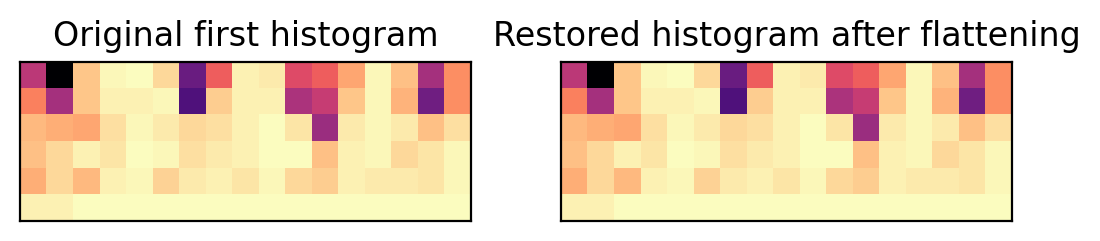

In [49]:
chromatin_gridder.create_deconvolution_matrices(True)

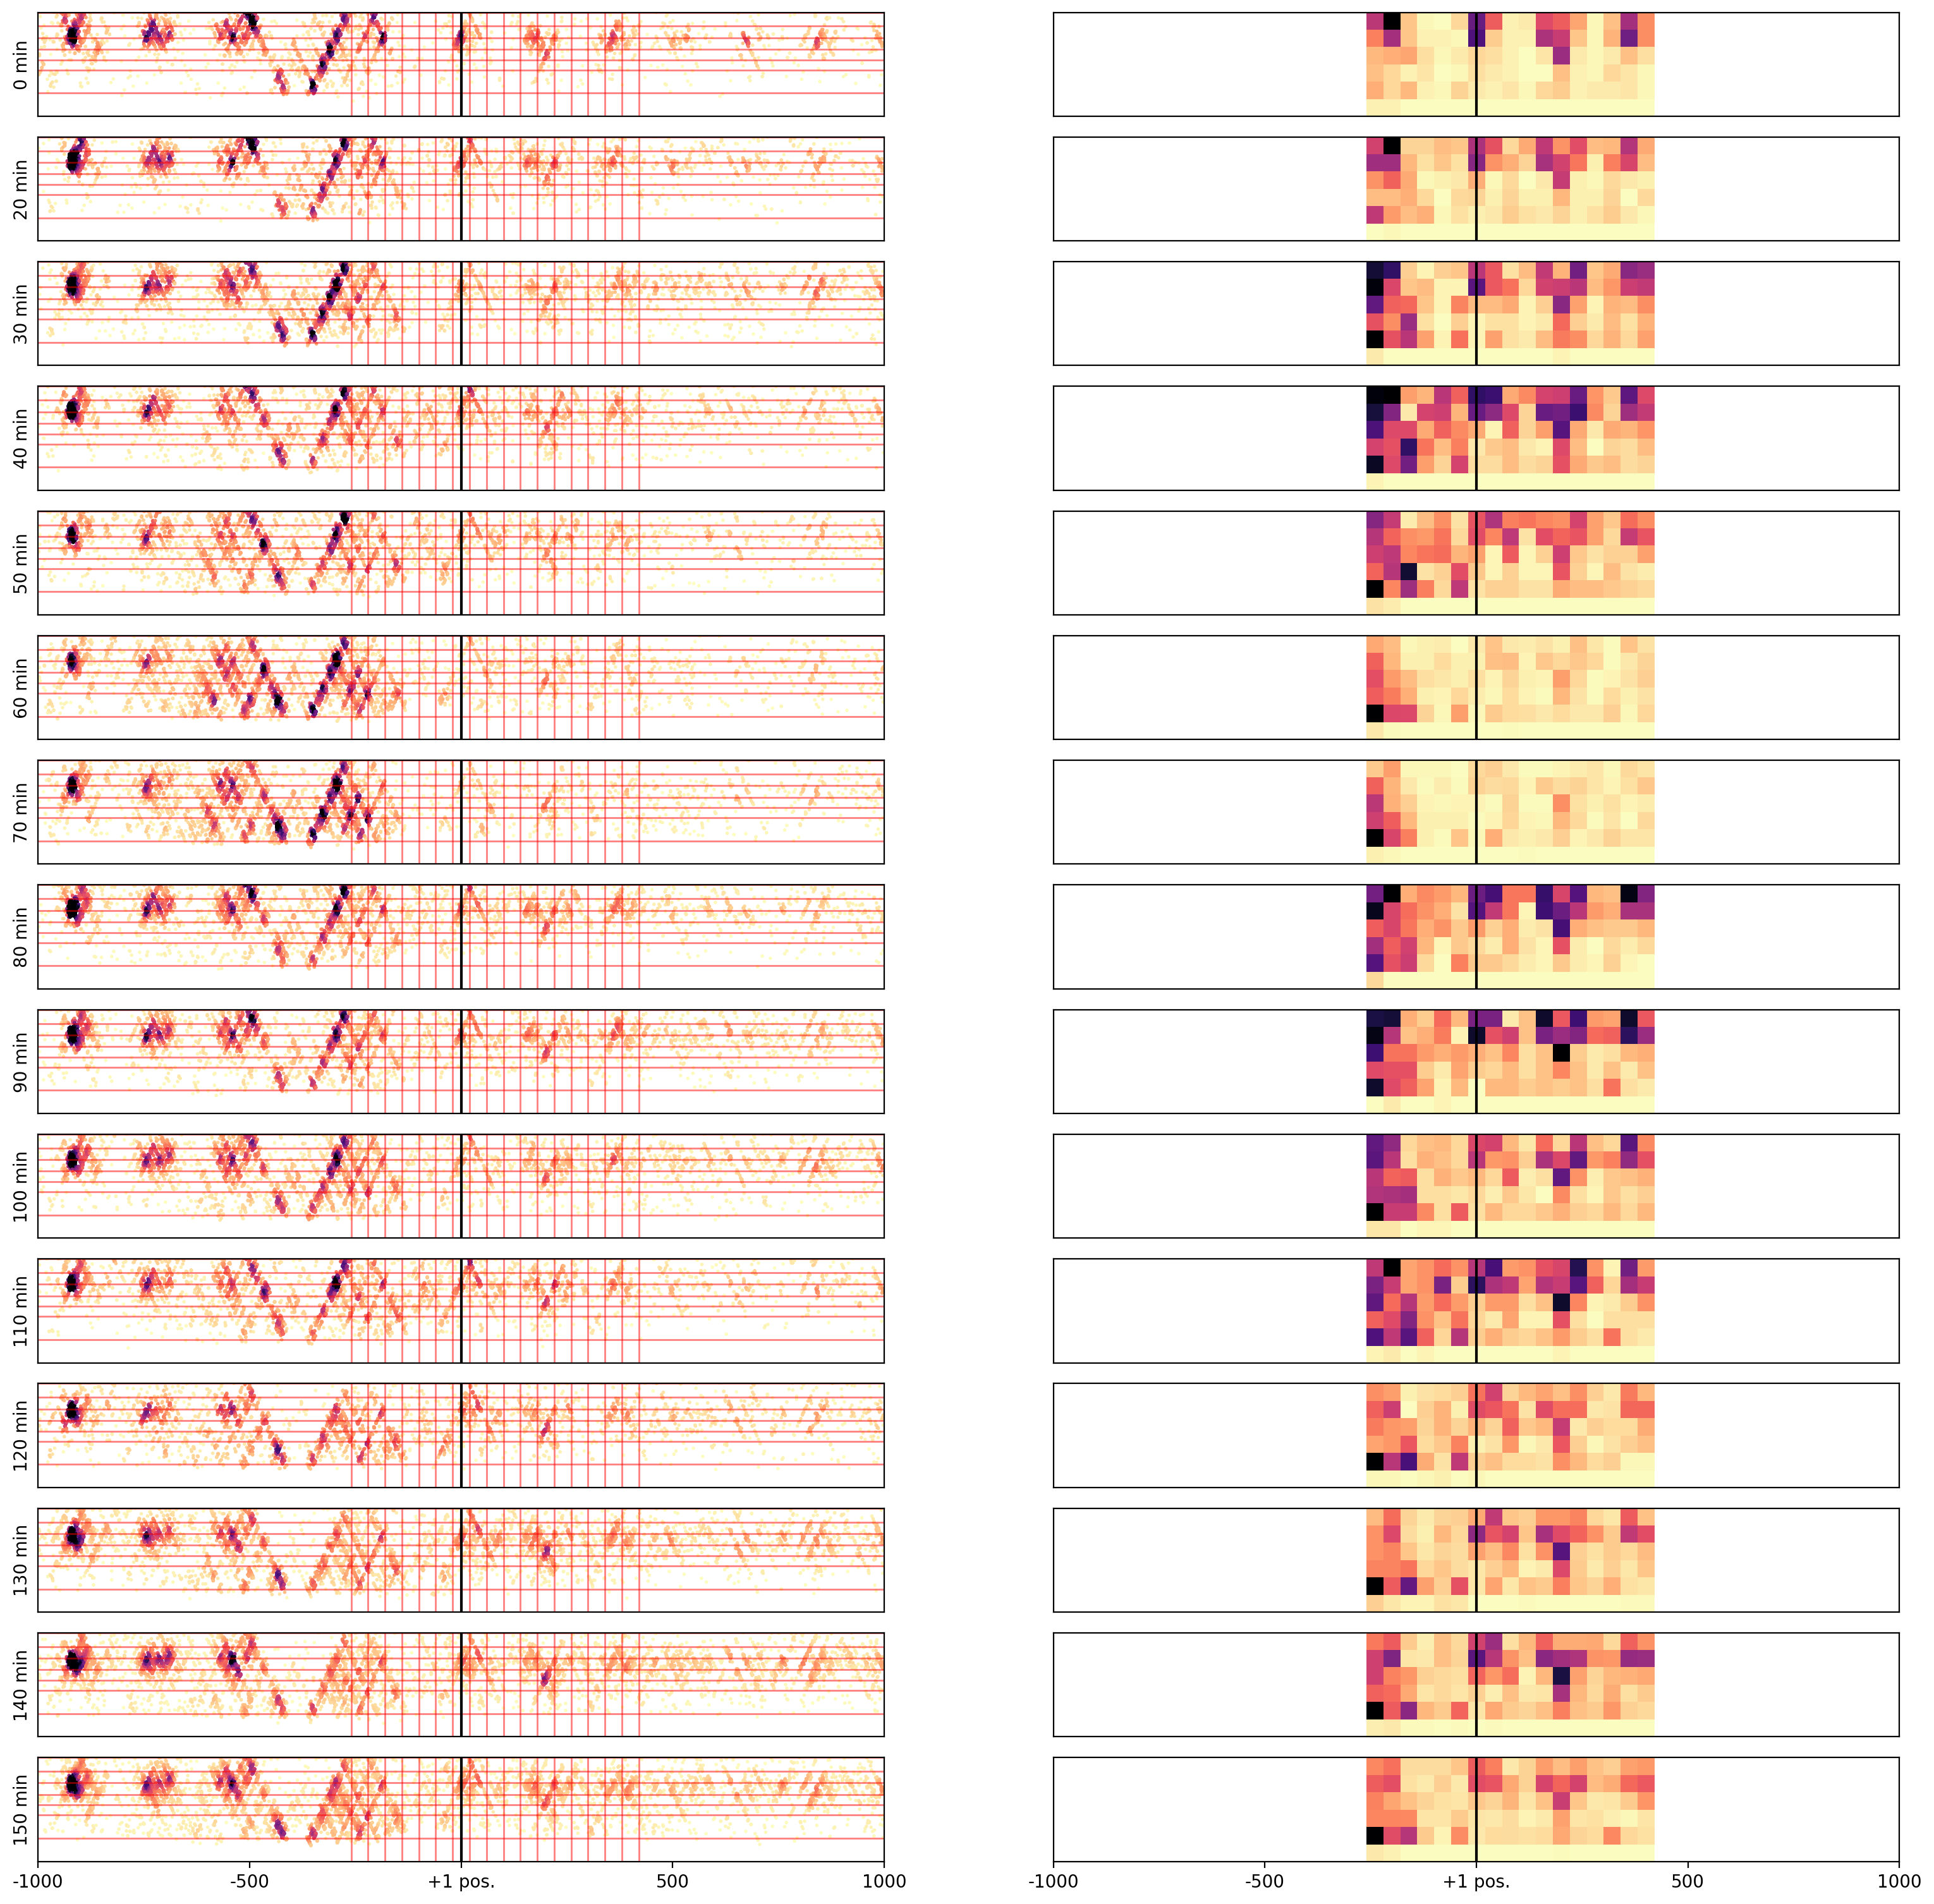

In [50]:
chromatin_gridder.plot_raw_and_grid()


In [51]:
from src.deconvolve_chromatin import deconvolve_chromatin
from src.timer import Timer

timer = Timer()

model1 = Model(config1, 'CLB2', 0.01)
deconvolve_chromatin(model1, chromatin_gridder.deconv_hist)
timer.get_time()


'01:48:06.67'

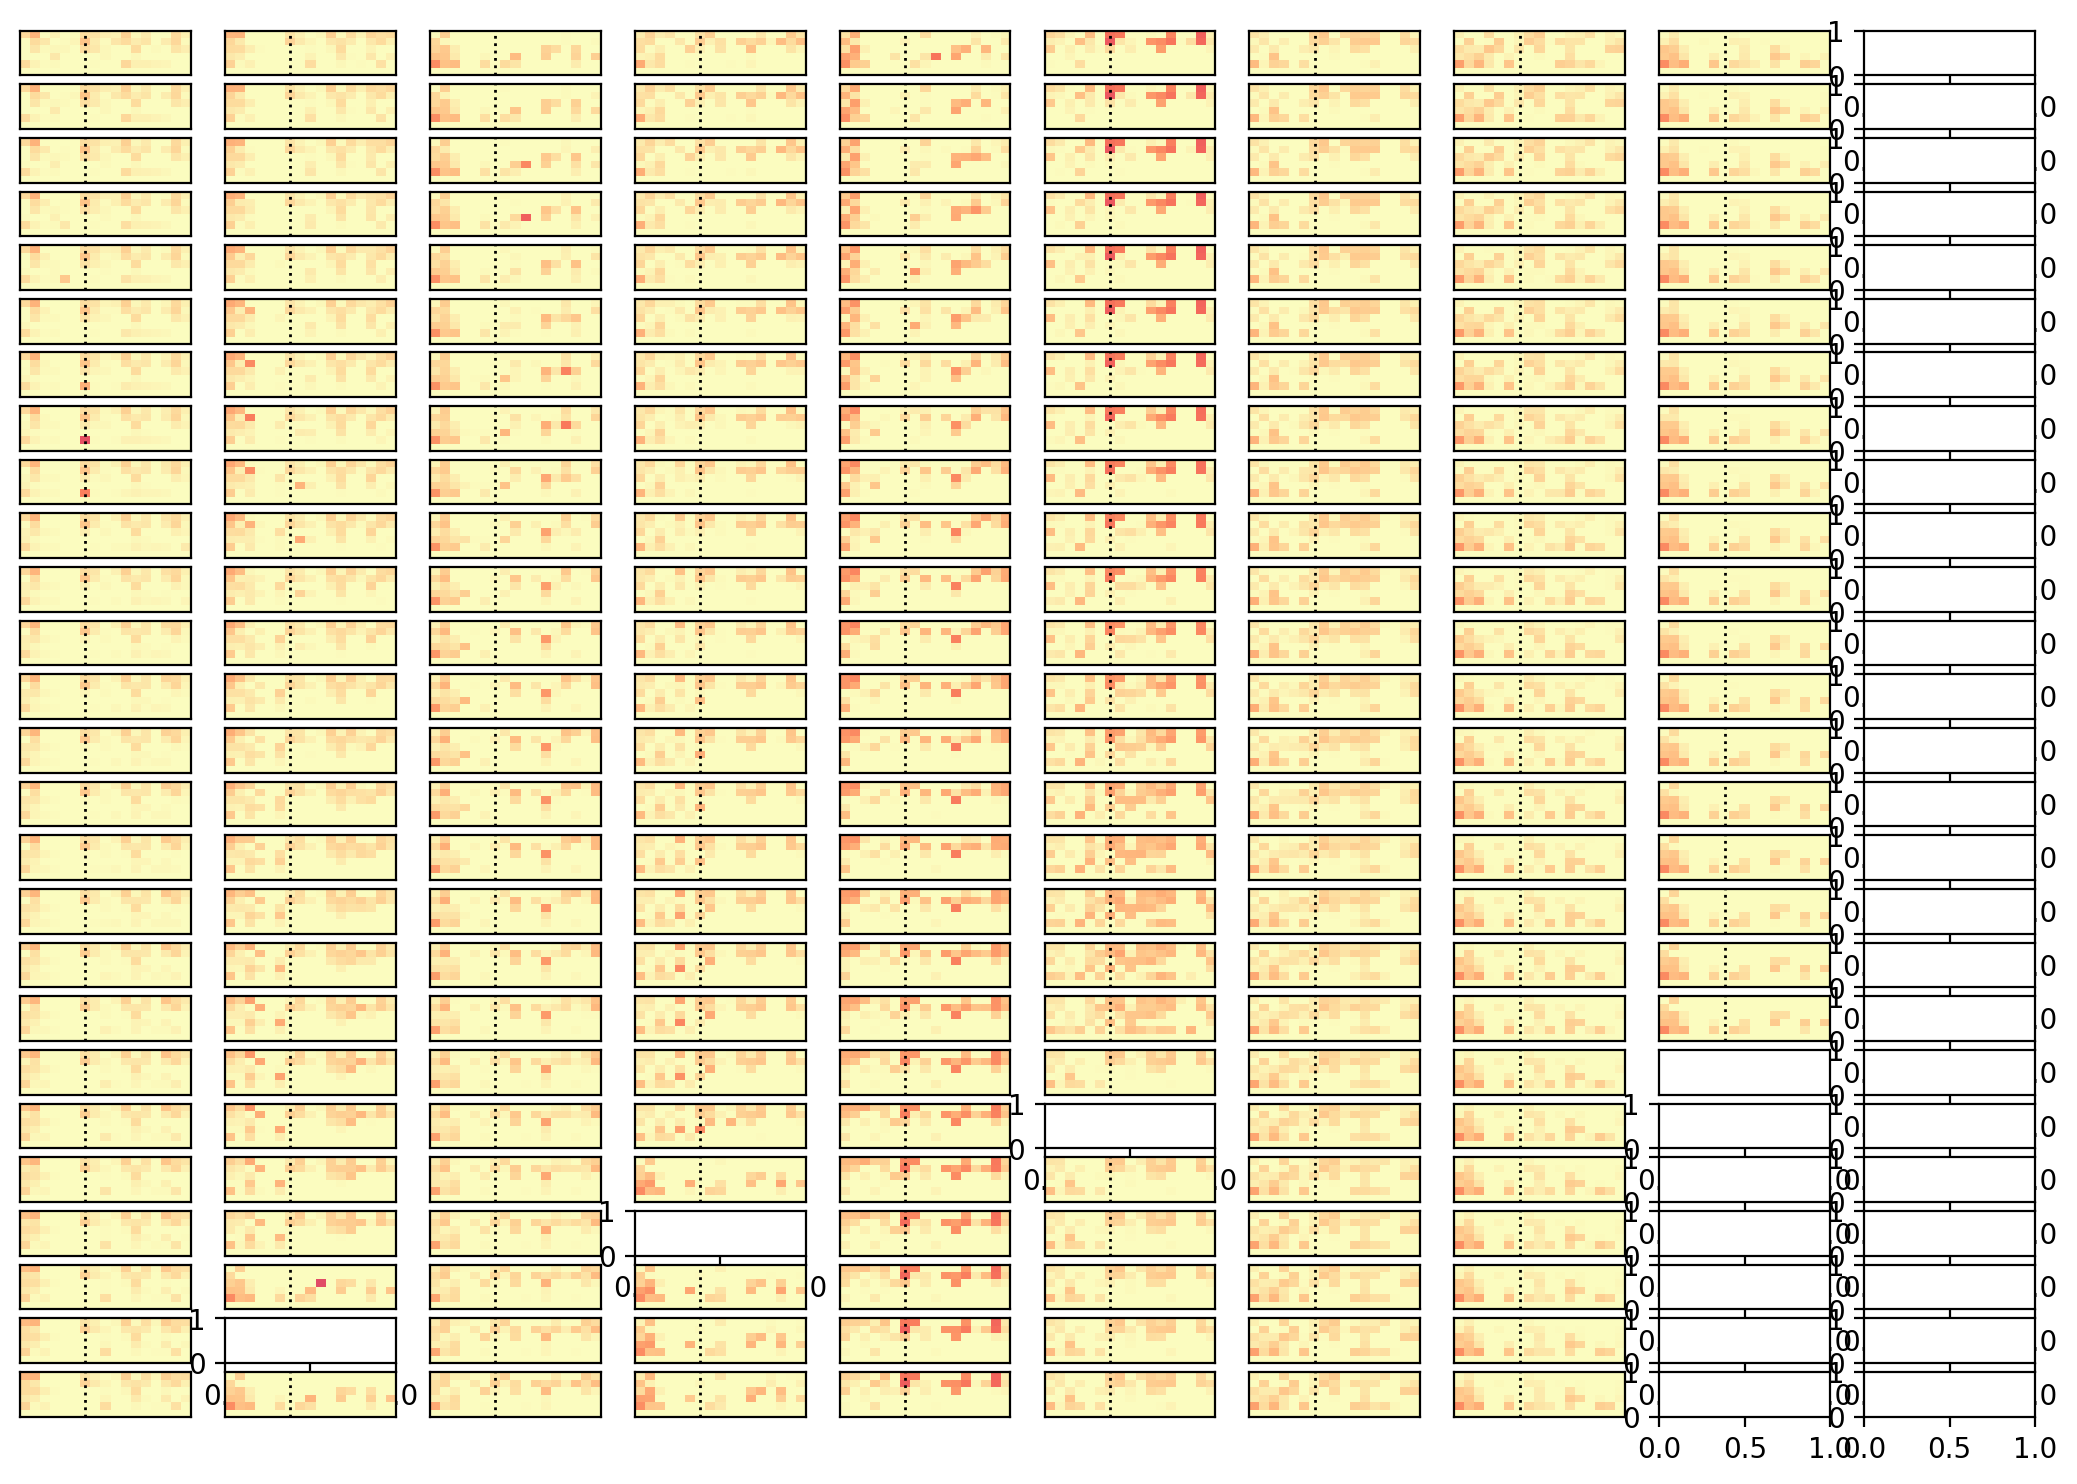

In [52]:
chromatin_gridder.create_deconvolution_plots_full(model1)

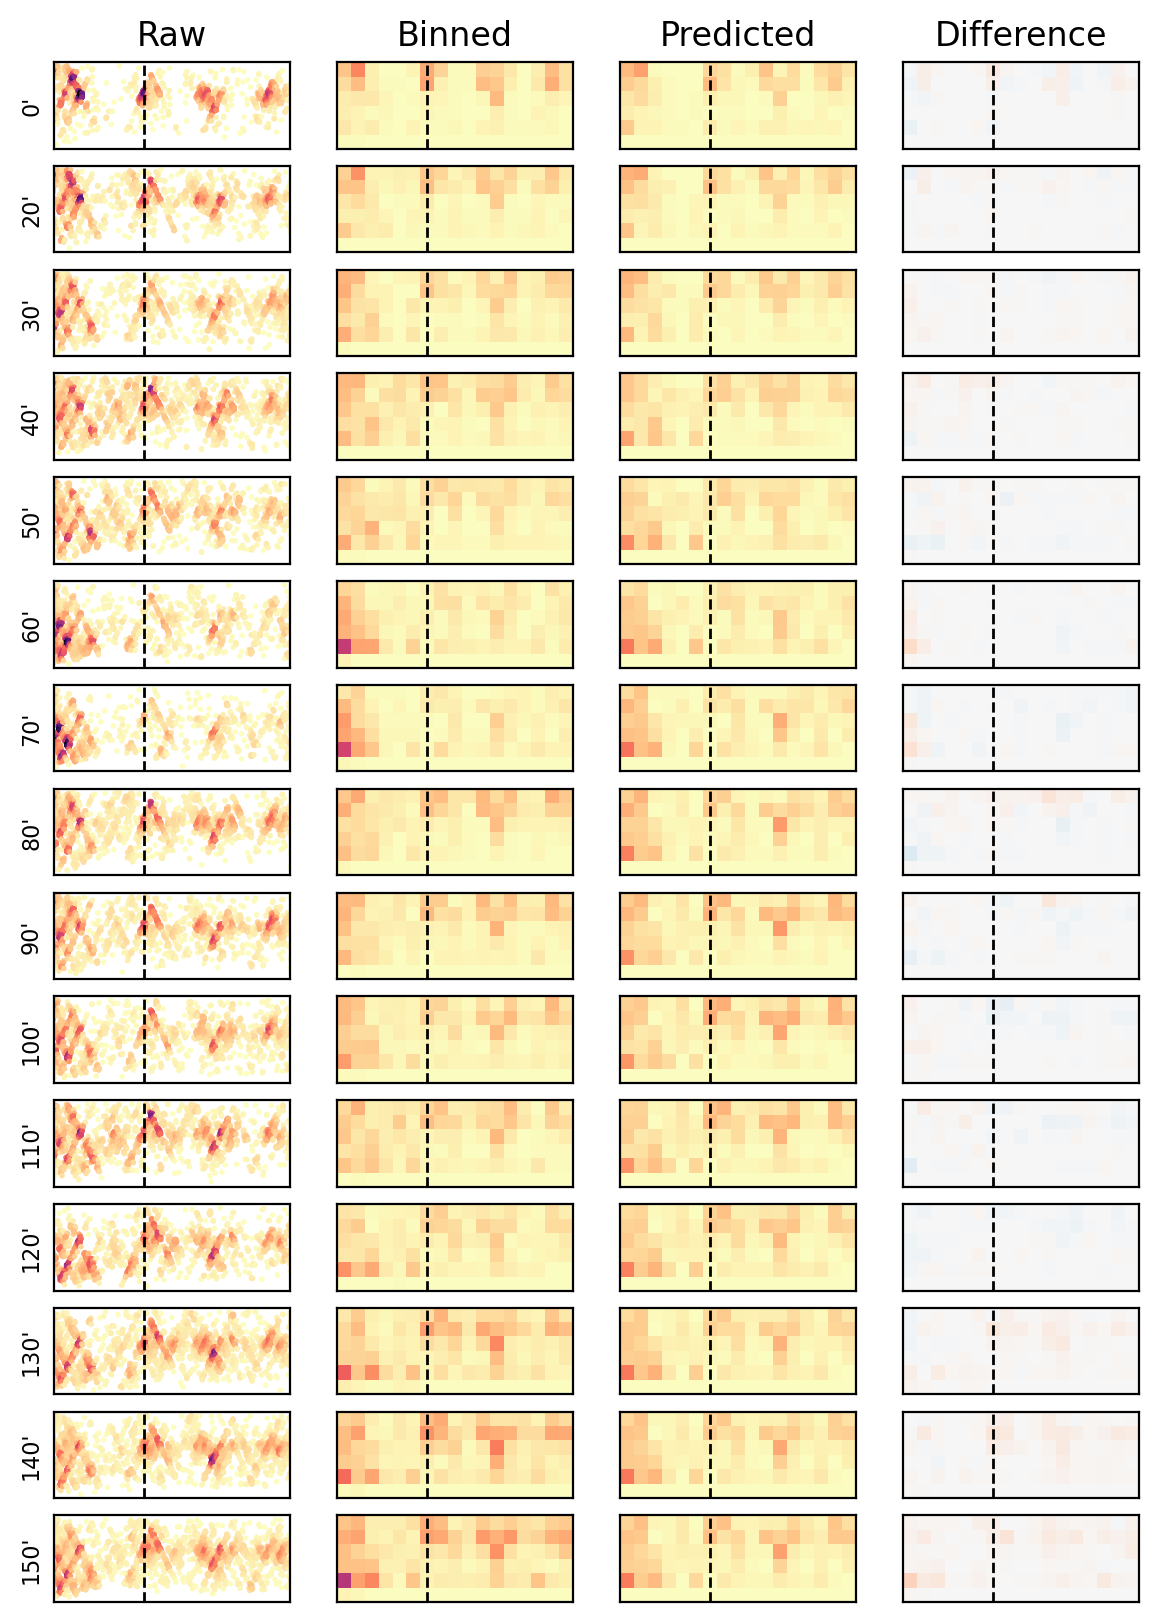

In [53]:
chromatin_gridder.plot_prediction_comparison(model1)

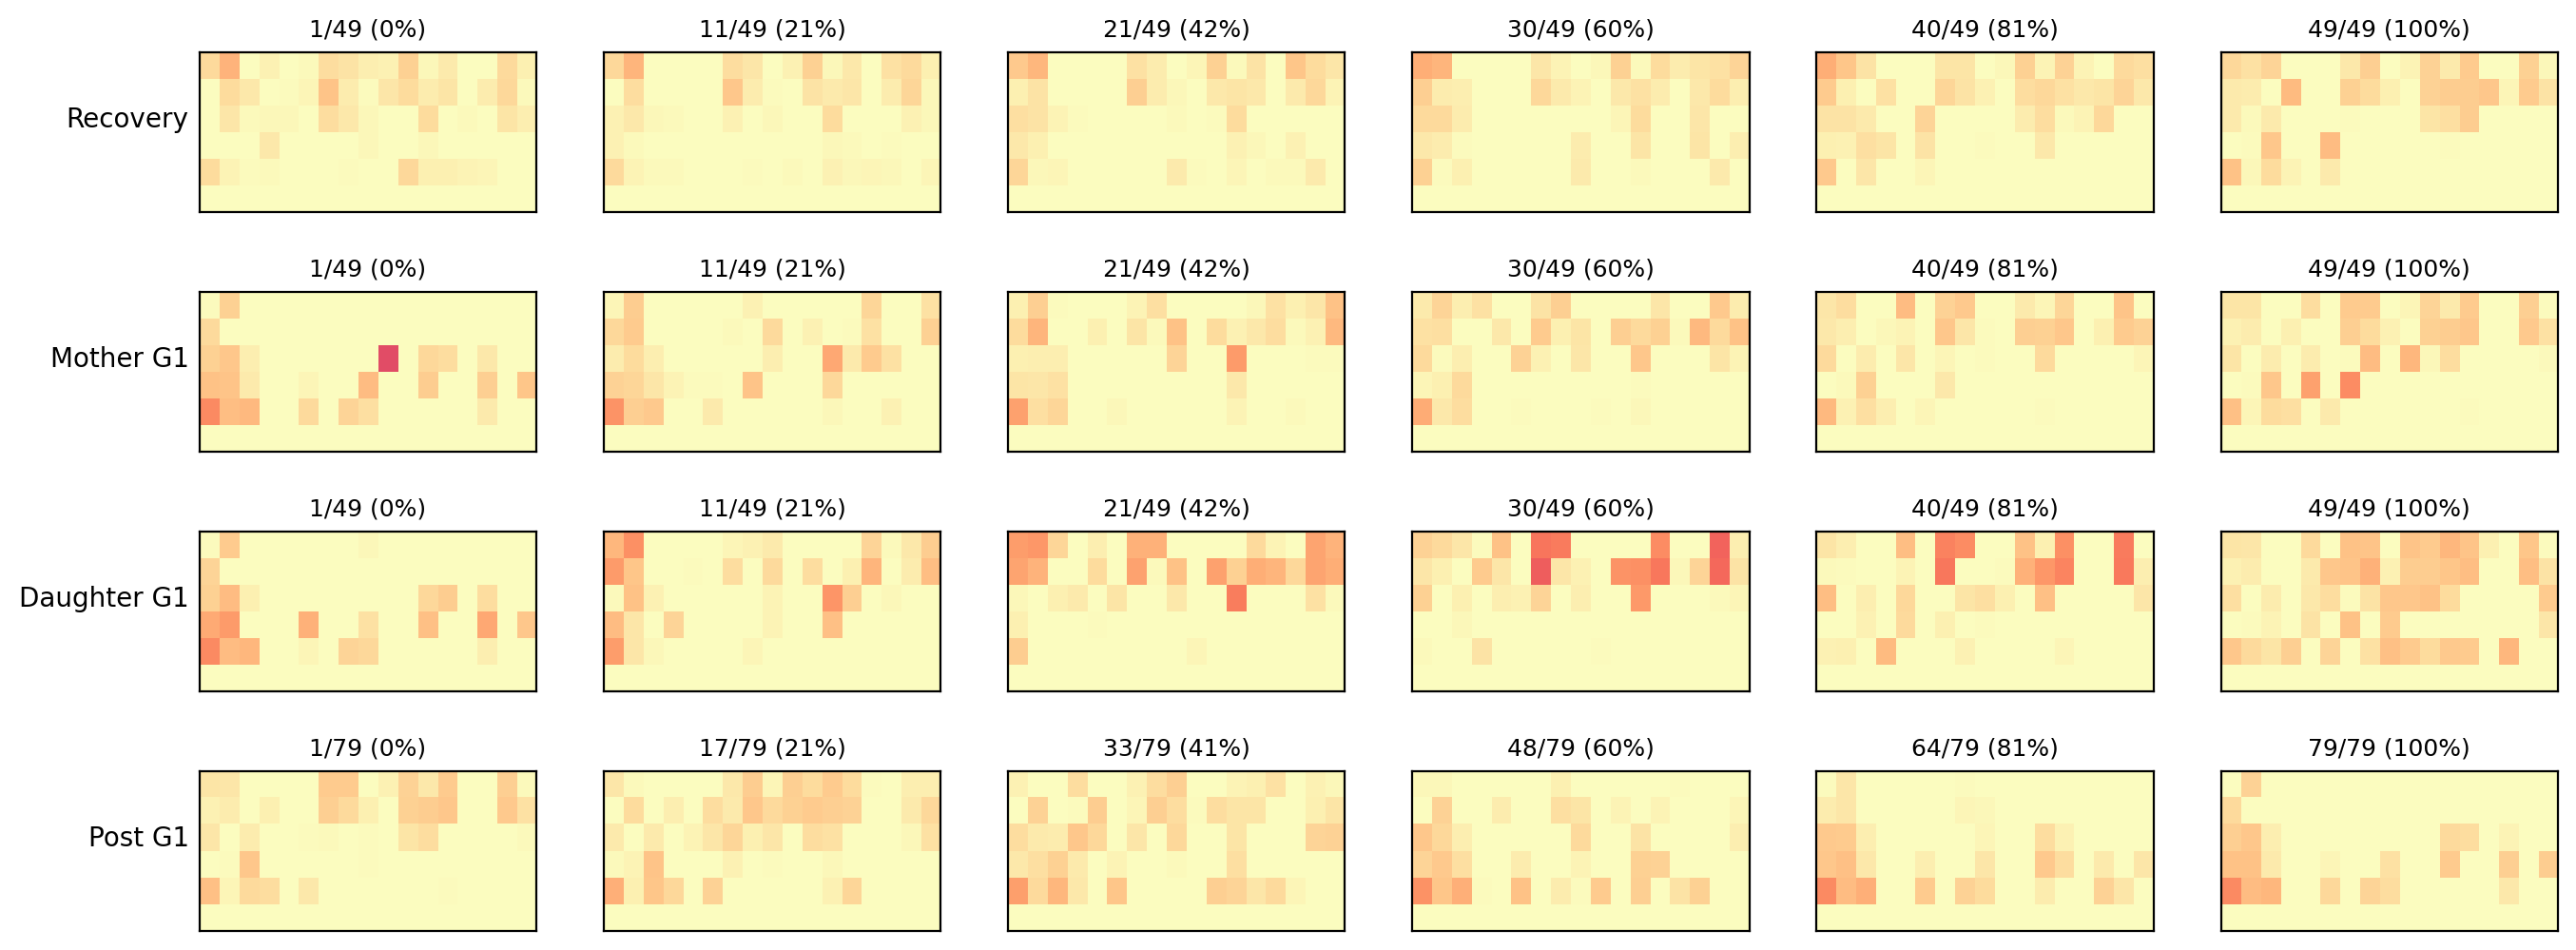

In [54]:
fig, ax_rows = plt.subplots(4, 6, figsize=(16, 6))
plt.subplots_adjust(hspace=0.5)
chromatin_gridder.create_deconvolution_plots_abbreviated(model1.f, 
    model1, ax_rows)


In [55]:
print(f"The fitting norm is {model1.rn:.2f}, the smoothing norm is: {model1.sn:.2f}")

The fitting norm is 632.35, the smoothing norm is: 151.05
